In [ ]:
# Naive Bayes kya hai?

# Naive Bayes ek supervised classification algorithm hai jo probability use karke prediction karta hai.

# Classic example: Spam Email Detection

# Email mein words aaye:

# "free"
# "offer"
# "win"
# "money"

# Model calculate karta hai:

# P(Spam | words)
# P(Not Spam | words)

# Jo probability zyada hogi, woh prediction.

In [1]:
# Bayes → Bayes' theorem/probability ka use.

# Naive → Ye assume karta hai ke features independent hain, yani ek feature ki presence doosre feature se independent hai.

In [3]:
# Naive Bayes ke different versions

# Ye important hai because sklearn mein different Naive Bayes classes milengi.

# 1. Gaussian Naive Bayes

# Continuous numerical data ke liye.

# Examples:

# Age
# Height
# Weight
# Salary
# Temperature
# Exam Score

# Sklearn:

# from sklearn.naive_bayes import GaussianNB
# 2. Multinomial Naive Bayes

# Mostly text/count data ke liye.

# Examples:

# word counts
# document classification
# spam detection
# news classification
# from sklearn.naive_bayes import MultinomialNB
# 3. Bernoulli Naive Bayes

# Binary features:

# word present = 1
# word absent  = 0
# from sklearn.naive_bayes import BernoulliNB

In [4]:
# Gausian NB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Dataset
data = {
    "Age": [
        22, 25, 27, 29, 31,
        35, 38, 40, 42, 45,
        48, 50, 52, 55, 58,
        60, 62, 65, 68, 70
    ],

    "Salary": [
        25000, 28000, 30000, 32000, 35000,
        40000, 42000, 45000, 48000, 52000,
        55000, 58000, 62000, 68000, 72000,
        78000, 82000, 88000, 95000, 105000
    ],

    "Purchased": [
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

print(df)

    Age  Salary  Purchased
0    22   25000          0
1    25   28000          0
2    27   30000          0
3    29   32000          0
4    31   35000          0
5    35   40000          0
6    38   42000          0
7    40   45000          0
8    42   48000          0
9    45   52000          0
10   48   55000          1
11   50   58000          1
12   52   62000          1
13   55   68000          1
14   58   72000          1
15   60   78000          1
16   62   82000          1
17   65   88000          1
18   68   95000          1
19   70  105000          1


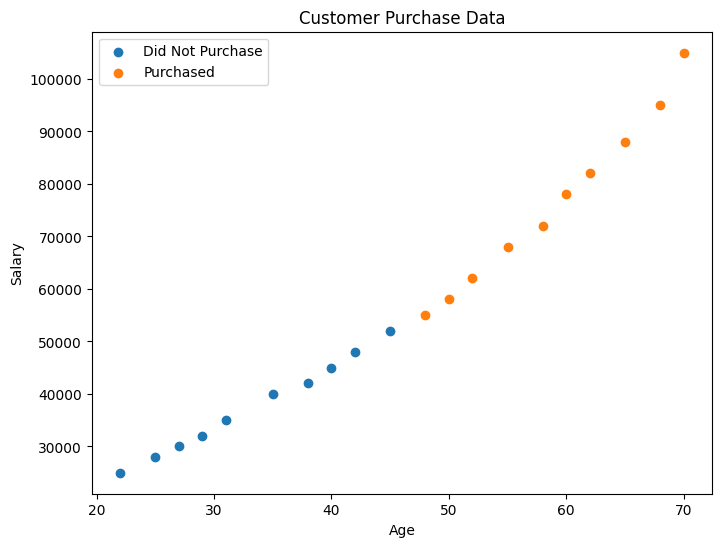

In [5]:
# visualize the data
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["Purchased"] == 0]["Age"],
    df[df["Purchased"] == 0]["Salary"],
    label="Did Not Purchase"
)

plt.scatter(
    df[df["Purchased"] == 1]["Age"],
    df[df["Purchased"] == 1]["Salary"],
    label="Purchased"
)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Customer Purchase Data")
plt.legend()
plt.show()

In [6]:
# model
X = df[["Age", "Salary"]]
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual:     ", y_test.values)

print("Accuracy:", accuracy_score(y_test, y_pred))

Predictions: [0 0 1 1 0]
Actual:      [0 0 1 1 0]
Accuracy: 1.0


In [10]:
# new customer prediction
new_customer = pd.DataFrame([[46, 60000]], columns=['Age', 'Salary'])
prediction = model.predict(new_customer)
probability = model.predict_proba(new_customer)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [1]
Probability: [[0.14236798 0.85763202]]


In [11]:
# This is very similar to what we saw in Logistic Regression: probability + final class.

# But the way probability is calculated is completely different.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


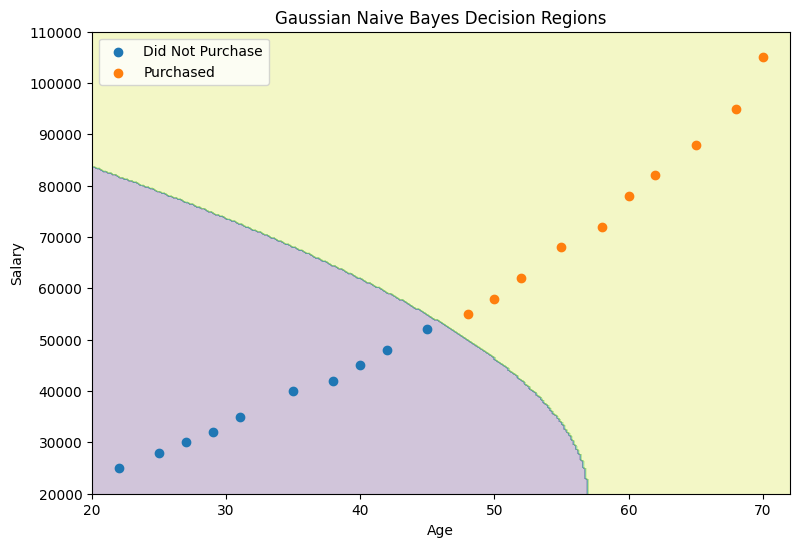

In [12]:
# Decision Boundary
# Create grid
age_min = X["Age"].min() - 2
age_max = X["Age"].max() + 2

salary_min = X["Salary"].min() - 5000
salary_max = X["Salary"].max() + 5000

age_grid, salary_grid = np.meshgrid(
    np.linspace(age_min, age_max, 300),
    np.linspace(salary_min, salary_max, 300)
)

grid = np.c_[
    age_grid.ravel(),
    salary_grid.ravel()
]

grid_predictions = model.predict(grid)

grid_predictions = grid_predictions.reshape(age_grid.shape)

plt.figure(figsize=(9, 6))

plt.contourf(
    age_grid,
    salary_grid,
    grid_predictions,
    alpha=0.25
)

plt.scatter(
    df[df["Purchased"] == 0]["Age"],
    df[df["Purchased"] == 0]["Salary"],
    label="Did Not Purchase"
)

plt.scatter(
    df[df["Purchased"] == 1]["Age"],
    df[df["Purchased"] == 1]["Salary"],
    label="Purchased"
)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Gaussian Naive Bayes Decision Regions")
plt.legend()
plt.show()

In [ ]:
# Naive Bayes kab use karein?

# Good:

# Spam detection
# Text classification
# Sentiment analysis
# News/document classification
# Small datasets
# Fast baseline classification
# High-dimensional text features

# Avoid / less ideal:

# Features strongly depend on each other
# Complex feature relationships matter
# You need very sophisticated nonlinear patterns
# Data doesn't fit the assumptions of the chosen NB variant

In [13]:
# Naive Bayes is a probabilistic supervised classification algorithm based on Bayes' theorem that predicts the class with the highest posterior probability while making a conditional independence assumption between features.

In [14]:
# sab classes me check karta ha k is class ki kitni probability ha and is me kitni ha

# fir jis me sab se high ho use consider karta ha